# Chemomile Hands-On Tutorial

Welcome! This tutorial is designed to be **"Run All"** safe. 

By clicking **Run All Cells**, this notebook will:
1. Load and visualize the combustion property dataset.
2. Perform a "Quick Training" cycle (5 epochs) to show you how the model learns.
3. Evaluate the newly trained model with parity plots.
4. Predict properties for a new molecule (e.g., Ethanol).
5. Generate a 3D explainability visualization (Atom Masking).

Feel free to run it all at once, walk away, and come back later to study the results and code!

## 1. Setup and Data Visualization
We start by setting up our environment and inspecting the data we will be training on.

In [1]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set the root directory for Chemomile
DATAROOT = "../"
sys.path.append(DATAROOT)

from src.data import Dataset
from src.model import Chemomile
from src.train import Training
from src.smiles2data import smiles2data
from src.explainer import Explainer

print("Environment ready!")
# Create model directory
os.makedirs("./tutorial_models", exist_ok=True)


Environment ready!


	DataDump (HDF5) found for 'ESOL'. Loading dumped data.


Training : 902 | Validation : 113 | Test : 113
Total : 1128


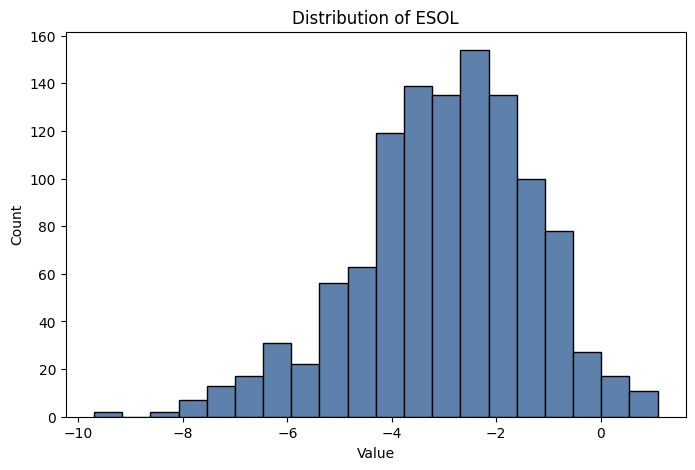

In [2]:
target = "ESOL" # Change this to AIT, HCOM, FLVL, or FLVU to explore others
dataset = Dataset(target=target, root=DATAROOT)

y_values = torch.cat([data.y for data in dataset.total_loader]).detach().numpy()
y_values = y_values * dataset.std + dataset.mean

plt.figure(figsize=(8, 5))
plt.hist(y_values, bins=20, color="#5E81AC", edgecolor="black")
plt.title(f"Distribution of {target}")
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()

## 2. Quick Training Cycle
Now we train a model. To keep this tutorial fast, we only run for **5 epochs**. In a real scenario, you would increase `max_epoch` to 100+.

In [3]:
parameters = dict(
    target = "ESOL",
    subfrag_size = 10,
    hidden_size = 32,
    edge_size = 3,
    out_size = 1,
    num_layers = 4,
    num_timesteps = 4,
    dropout = 0.2,
    lr_init = 0.001,
    gamma = 0.98,
    weight_decay = 1e-4,
    seed = 42,
    batch_size = 64,
    max_epoch = 5, # QUICK TRAINING FOR TUTORIAL
    verbose = True,
    save = True
)

model = Chemomile(
    subfrag_size=parameters["subfrag_size"],
    hidden_size=parameters["hidden_size"],
    edge_size=parameters["edge_size"],
    out_size=parameters["out_size"],
    dropout=parameters["dropout"],
    num_layers=parameters["num_layers"],
    num_timesteps=parameters["num_timesteps"]
)

training_session = Training(
    model=model,
    parameters=parameters,
    dataset=dataset,
    root="./tutorial_models"
)

print("Starting Quick Training...")
training_session.run()
print("Training complete!")

Output()

Starting Quick Training...


| Epoch :    0 | Trn. Loss : 7.487e-01 | Val. Loss : 4.305e-01 | LR : 1.000e-03 |

Saving the best model with valLoss : 0.430

| Epoch :    1 | Trn. Loss : 4.806e-01 | Val. Loss : 3.023e-01 | LR : 9.800e-04 |

...

Saving the best model with valLoss : 0.272

| Epoch :    3 | Trn. Loss : 3.583e-01 | Val. Loss : 1.780e-01 | LR : 9.412e-04 |

Saving the best model with valLoss : 0.178

| Epoch :    4 | Trn. Loss : 2.642e-01 | Val. Loss : 2.032e-01 | LR : 9.224e-04 |

Training complete!


## 3. Evaluation
Let"""s see how well our quick training performed. We plot the loss curve and a parity plot.

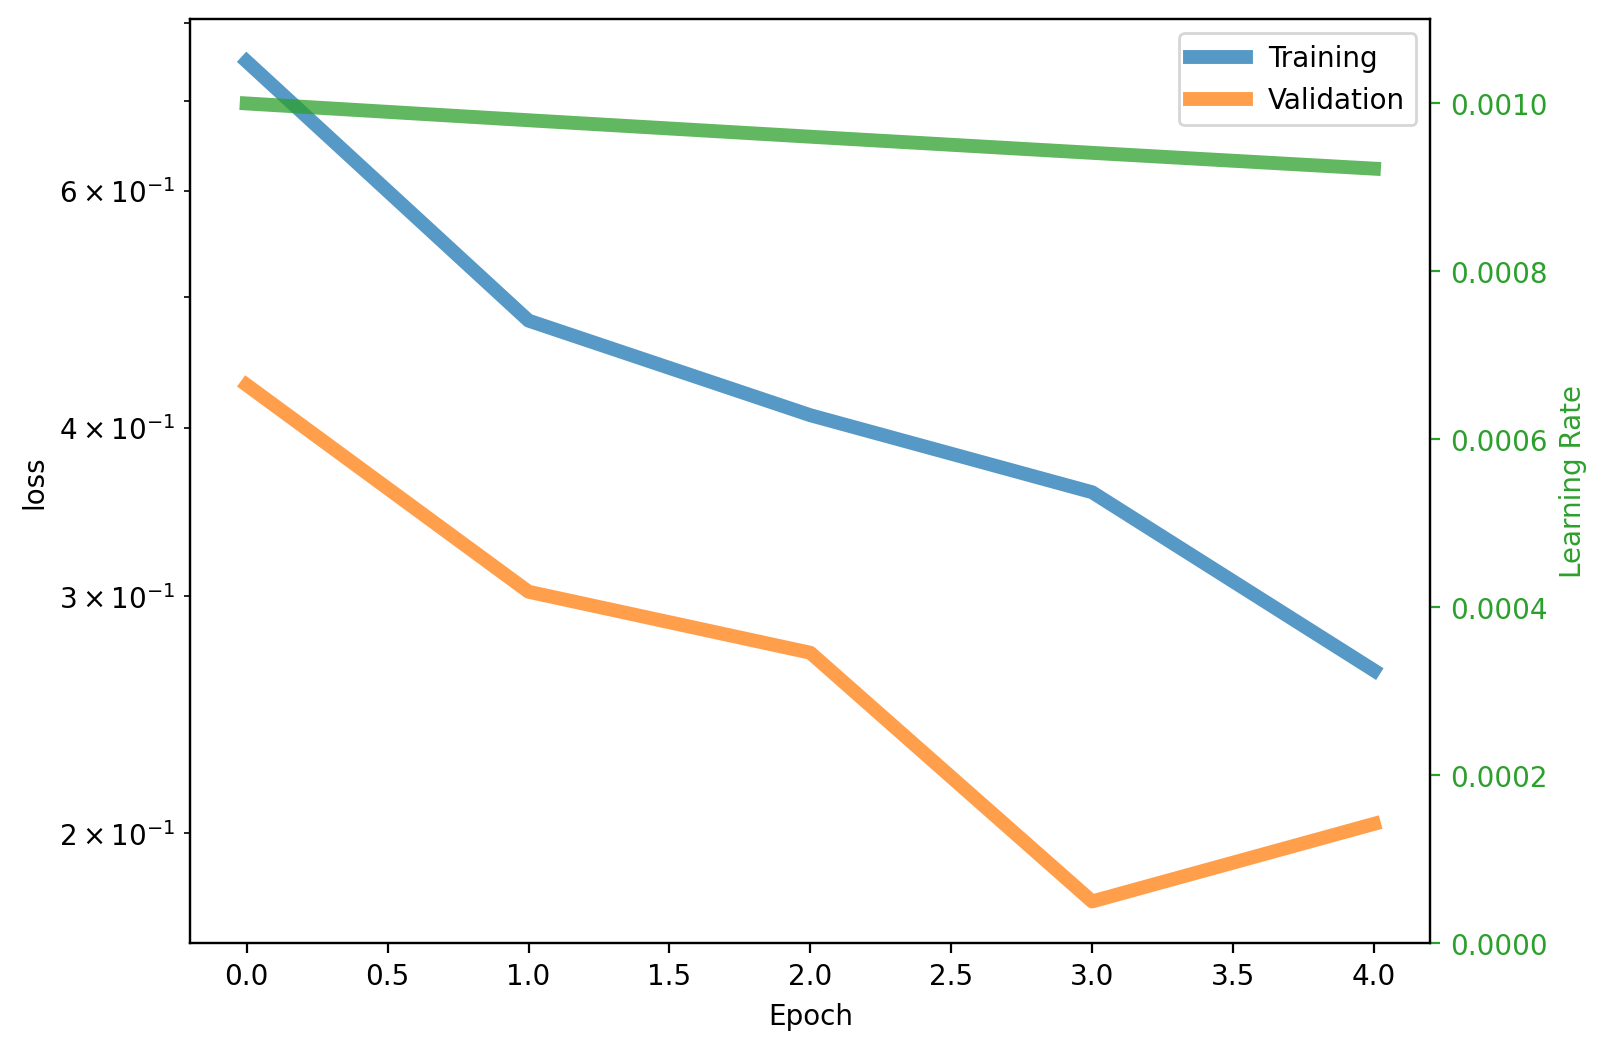

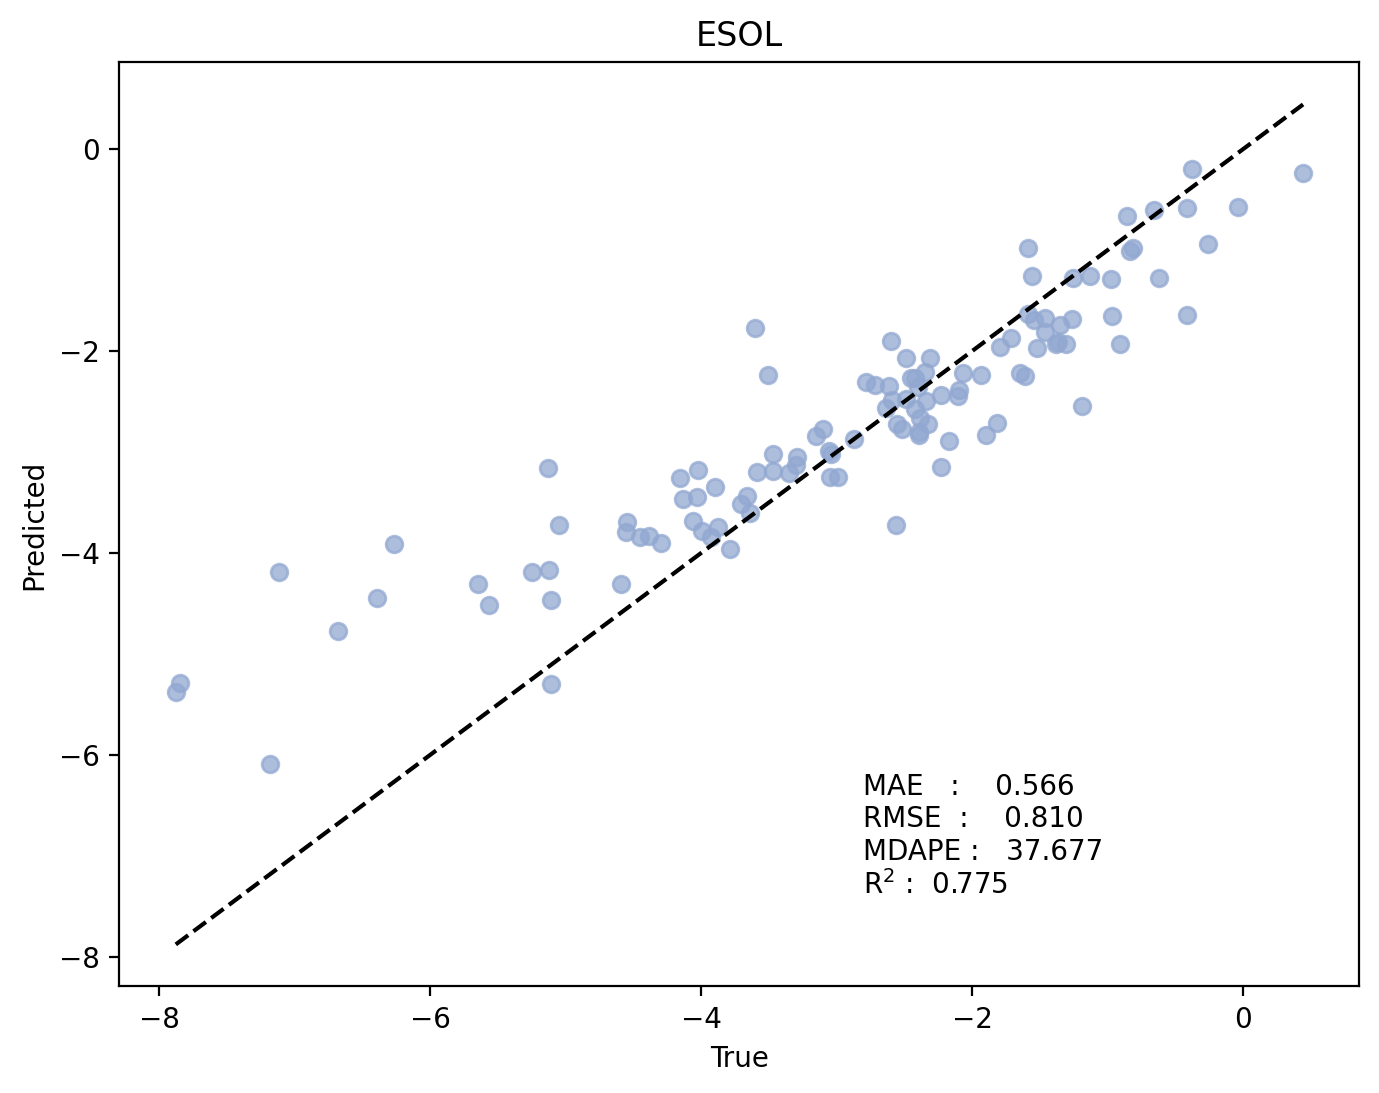

In [4]:
training_session.lossCurve()
training_session.TPPlot()

## 4. Predict on a New Molecule
We can now use the model we just trained to predict the property of a completely new SMILES string.

In [5]:
SMILES = "CCO" # Ethanol # Ethanol. Try changing this to your favorite molecule!
TRUE_VAL = 0.5 # Known FP for Ethanol (approx)

data_obj = smiles2data(SMILES, TRUE_VAL)

explainer = Explainer(model=model, data=data_obj)

prediction_scaled = explainer.ref
prediction_actual = prediction_scaled * dataset.std + dataset.mean

print(f"SMILES: {SMILES}")
print(f"Predicted {target}: {prediction_actual:.2f} log mol/L")

SMILES: CCO
Predicted ESOL: -0.50 log mol/L


## 5. Explainability (Atom Masking)
Finally, we visualize *why* the model made that prediction. We use Atom Masking to find which atoms contribute most to the property.

Atom Scores (relative contribution):
[tensor([0.0363]), tensor([-0.2426]), tensor([-0.4021]), tensor([0.0317]), tensor([0.0309]), tensor([0.0306]), tensor([-0.0493]), tensor([-0.0494]), tensor([-0.0814])]


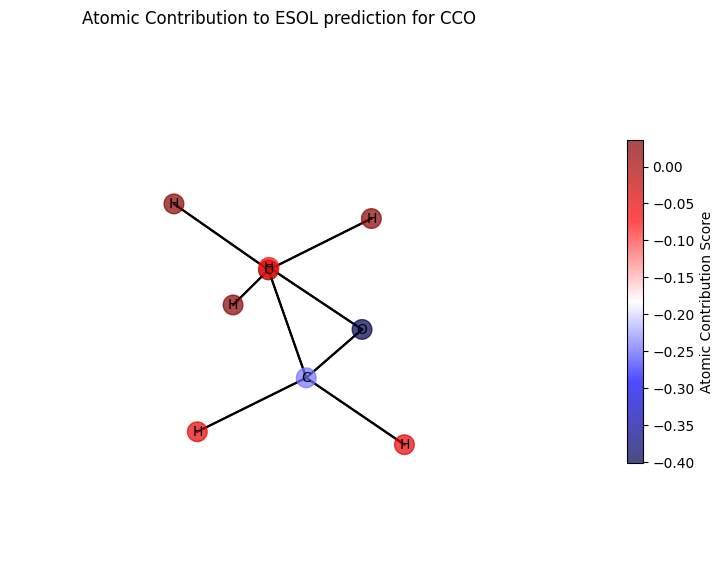

In [6]:
scores = explainer.atomMask()
print("Atom Scores (relative contribution):")
print(scores)

fig, ax = plt.subplots(1, 1, figsize=(10, 7), subplot_kw=dict(projection="3d"))
im = explainer.plot(ax) # Capture the mapping for the colorbar
plt.title(f"Atomic Contribution to {target} prediction for {SMILES}")

# Add colorbar to explain the atomic scores
cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label("Atomic Contribution Score")

plt.show()